In [ ]:
#!/usr/bin/env python3

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

# define a function to parse the minimap output
def parse_minimap_output(file_path):
    # read the minimap output into a pandas DataFrame
    col_names=['qname', 'qlen', 'qstart', 'qend', 'strand', 'tname', 'tlen', 'tstart', 'tend', 'nmatch', 'alnlen']
    df = pd.read_csv(file_path, sep='\t', header=None)
    #keep only the first 11 columns
    df = df.iloc[:, :11]
    df.columns = col_names
    return df

# define a function to calculate % identity % query coverage and % target coverage from the minimap output
def calculate_id_qc(df):
    df['id'] = df['nmatch'] / df['alnlen'] * 100
    df['qc'] = (df['qend'] - df['qstart']) / df['qlen'] * 100
    df['tc'] = (df['tend'] - df['tstart']) / df['tlen'] * 100
    return df

def find_by_aro(card_data, target_aro):
    results = []
    if isinstance(card_data, dict):
        if card_data.get('ARO_accession') == target_aro:
            results.append(card_data)
        for v in card_data.values():
            results.extend(find_by_aro(v, target_aro))
    elif isinstance(card_data, list):
        for item in card_data:
            results.extend(find_by_aro(item, target_aro))
    return results

def get_aro_categories(aros, card_data):
    categories = {}
    for aro in aros:
        results = find_by_aro(card_data, aro)
        if len(results) == 0:
            print(f'ARO {aro} not found in CARD JSON data')
            continue
        aro_category = results[0]['ARO_category']
        first_key = next(iter(aro_category))
        category_aro_accession = aro_category[first_key]['category_aro_accession']
        category_aro_name = aro_category[first_key]['category_aro_name']
        categories[aro] = (category_aro_accession, category_aro_name)
    return categories

# read in the minimap output files 
every_path = parse_minimap_output('./every_path.tsv')
every_tax = parse_minimap_output('./every_tax.tsv')
every_red_rem = parse_minimap_output('./every_red_rem.tsv')
every_read_fil = parse_minimap_output('./every_read_fil.tsv')
every_final = parse_minimap_output('./every_final.tsv')
# calculate % identity and % query coverage for each file
every_path = calculate_id_qc(every_path)
every_tax = calculate_id_qc(every_tax)
every_red_rem = calculate_id_qc(every_red_rem)
every_read_fil = calculate_id_qc(every_read_fil)
every_final = calculate_id_qc(every_final)

# keep only alignments >90% target coverage
every_path = every_path[(every_path['tc'] > 90)]
every_tax = every_tax[(every_tax['tc'] > 90)]
every_red_rem = every_red_rem[(every_red_rem['tc'] > 90)]
every_read_fil = every_read_fil[(every_read_fil['tc'] > 90)]
every_final = every_final[(every_final['tc'] > 90)]

# investigate which AROs are lost at each step
# read in reference ARO list
filenames = pd.read_csv('./all_ref_filenames.txt', header=None, names=['filename'])

# extract accession, contig, position, and aro from filename
# accession is character 2-16
filenames['accession'] = filenames['filename'].str[1:16]
# aro begins with "300" and is followed by 4 digits
filenames['aro'] = filenames['filename'].str.extract(r'(300\d{4})')

# save aro set 
reference_aros = set(filenames['aro'])

# extract aro from each minimap output and save as a set
every_path_aros = set(every_path['qname'].str.extract(r'(300\d{4})')[0])
every_tax_aros = set(every_tax['qname'].str.extract(r'(300\d{4})')[0])
every_red_rem_aros = set(every_red_rem['qname'].str.extract(r'(300\d{4})')[0])
every_read_fil_aros = set(every_read_fil['qname'].str.extract(r'(300\d{4})')[0])
every_final_aros = set(every_final['qname'].str.extract(r'(300\d{4})')[0])

# calculate which AROs are lost at each step
lost_every_path = reference_aros - every_path_aros
lost_every_tax = every_path_aros - every_tax_aros
lost_every_red_rem = every_tax_aros - every_red_rem_aros
lost_every_read_fil = every_red_rem_aros - every_read_fil_aros
lost_every_final = every_read_fil_aros - every_final_aros

# print the number of AROs lost at each step
print(f'AROs lost at every_path step: {len(lost_every_path)}')
print(f'AROs lost at every_tax step: {len(lost_every_tax)}')
print(f'AROs lost at every_red_rem step: {len(lost_every_red_rem)}')
print(f'AROs lost at every_read_fil step: {len(lost_every_read_fil)}')
print(f'AROs lost at every_final step: {len(lost_every_final)}')

# load the CARD JSON data
with open('./card.json') as f:
    card_data = json.load(f)

# for each lost_ set, match the ARO to the category_aro_accession in the CARD JSON data
lost_every_path_categories = get_aro_categories(lost_every_path, card_data)
print(f'Length of lost_every_path_categories: {len(lost_every_path_categories)}')
lost_every_tax_categories = get_aro_categories(lost_every_tax, card_data)
print(f'Length of lost_every_tax_categories: {len(lost_every_tax_categories)}')
lost_every_red_rem_categories = get_aro_categories(lost_every_red_rem, card_data)
print(f'Length of lost_every_red_rem_categories: {len(lost_every_red_rem_categories)}')
lost_every_read_fil_categories = get_aro_categories(lost_every_read_fil, card_data)
print(f'Length of lost_every_read_fil_categories: {len(lost_every_read_fil_categories)}')
lost_every_final_categories = get_aro_categories(lost_every_final, card_data)
print(f'Length of lost_every_final_categories: {len(lost_every_final_categories)}')

# print number of unique categories lost at each step
print(f'Unique categories lost at every_path step: {len(set(lost_every_path_categories.values()))}')
print(f'Unique categories lost at every_tax step: {len(set(lost_every_tax_categories.values()))}')
print(f'Unique categories lost at every_red_rem step: {len(set(lost_every_red_rem_categories.values()))}')
print(f'Unique categories lost at every_read_fil step: {len(set(lost_every_read_fil_categories.values()))}')
print(f'Unique categories lost at every_final step: {len(set(lost_every_final_categories.values()))}')

# save the lost_ dictionaries to csv files
pd.DataFrame.from_dict(lost_every_path_categories, orient='index', columns=['category_aro_accession', 'category_aro_name']).to_csv('./lost_every_path_categories.csv')
pd.DataFrame.from_dict(lost_every_tax_categories, orient='index', columns=['category_aro_accession', 'category_aro_name']).to_csv('./lost_every_tax_categories.csv')
pd.DataFrame.from_dict(lost_every_red_rem_categories, orient='index', columns=['category_aro_accession', 'category_aro_name']).to_csv('./lost_every_red_rem_categories.csv')
pd.DataFrame.from_dict(lost_every_read_fil_categories, orient='index', columns=['category_aro_accession', 'category_aro_name']).to_csv('./lost_every_read_fil_categories.csv')
pd.DataFrame.from_dict(lost_every_final_categories, orient='index', columns=['category_aro_accession', 'category_aro_name']).to_csv('./lost_every_final_categories.csv')

/tmp/ipykernel_2528236/1345847601.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


AROs lost at every_path step: 194
AROs lost at every_tax step: 9
AROs lost at every_red_rem step: 9
AROs lost at every_read_fil step: 79
AROs lost at every_final step: 0
ARO 3003985 not found in CARD JSON data
Length of lost_every_path_categories: 193
Length of lost_every_tax_categories: 9
Length of lost_every_red_rem_categories: 9
Length of lost_every_read_fil_categories: 79
Length of lost_every_final_categories: 0
Unique categories lost at every_path step: 59
Unique categories lost at every_tax step: 6
Unique categories lost at every_red_rem step: 9
Unique categories lost at every_read_fil step: 29
Unique categories lost at every_final step: 0


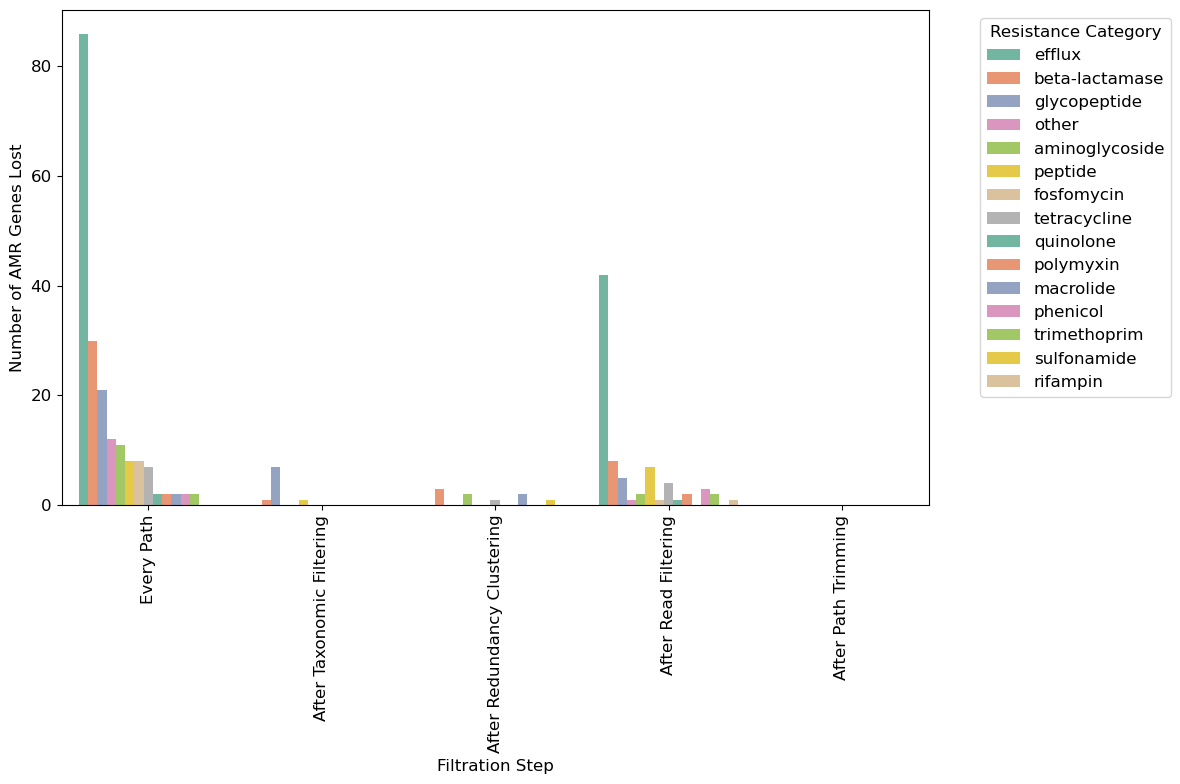

/tmp/ipykernel_2528236/2344325347.py:211: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=step, y=path_counts, palette='Set2', label='Total Paths', legend=False)


<Figure size 640x480 with 0 Axes>

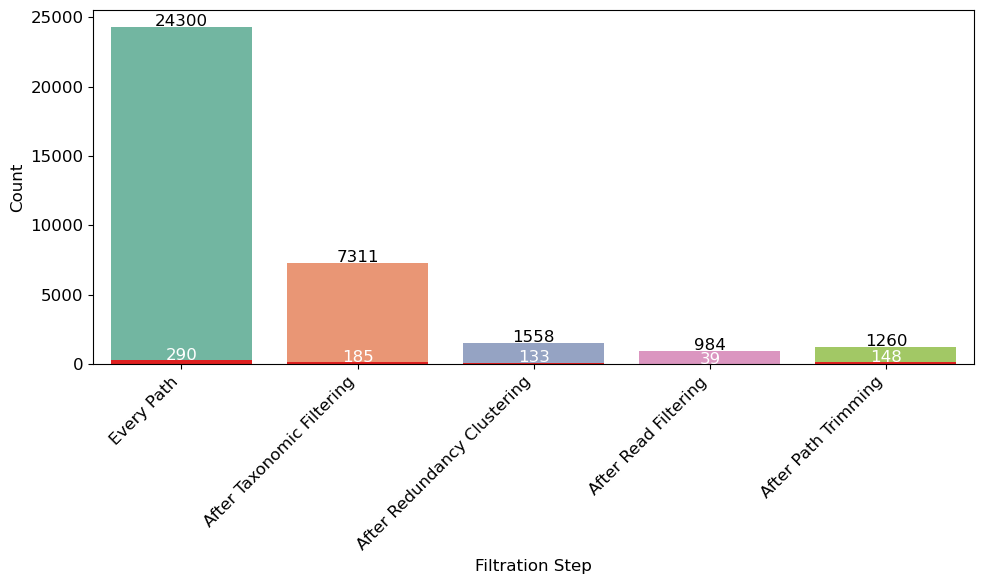

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# read in lost_ csvs

lost_every_path = pd.read_csv('./lost_every_path_categories.csv')
lost_every_tax = pd.read_csv('./lost_every_tax_categories.csv')
lost_every_red_rem = pd.read_csv('./lost_every_red_rem_categories.csv')
lost_every_read_fil = pd.read_csv('./lost_every_read_fil_categories.csv')
lost_every_final = pd.read_csv('./lost_every_final_categories.csv')

# change column names to ARO, category_aro_accession, category_aro_name
lost_every_path.columns = ['ARO', 'category_aro_accession', 'category_aro_name']
lost_every_tax.columns = ['ARO', 'category_aro_accession', 'category_aro_name']
lost_every_red_rem.columns = ['ARO', 'category_aro_accession', 'category_aro_name']
lost_every_read_fil.columns = ['ARO', 'category_aro_accession', 'category_aro_name']
lost_every_final.columns = ['ARO', 'category_aro_accession', 'category_aro_name']


# create a function to add a column called resistance_category with the following rules:
def add_resistance_category(df):
    # if df has no rows, return the df with an empty resistance_category column
    if df.empty:
        df['resistance_category'] = []
        return df
    # loop through the category_aro_name column and assign a resistance category based on the following rules:
    for index, row in df.iterrows():
        if 'beta-lactamase' in str(row['category_aro_name']):
            df.at[index, 'resistance_category'] = 'beta-lactamase'
        elif 'glycopeptide' in str(row['category_aro_name']):
            df.at[index, 'resistance_category'] = 'glycopeptide'
        elif 'van' in str(row['category_aro_name']):
            df.at[index, 'resistance_category'] = 'glycopeptide'
        elif 'ANT' in str(row['category_aro_name']):
            df.at[index, 'resistance_category'] = 'aminoglycoside'
        elif 'APH' in str(row['category_aro_name']):
            df.at[index, 'resistance_category'] = 'aminoglycoside'
        elif 'AAC' in str(row['category_aro_name']):
            df.at[index, 'resistance_category'] = 'aminoglycoside'
        elif 'tetracycline' in str(row['category_aro_name']):
            df.at[index, 'resistance_category'] = 'tetracycline'
        elif 'macrolide' in str(row['category_aro_name']):
            df.at[index, 'resistance_category'] = 'macrolide'
        elif 'peptide' in str(row['category_aro_name']):
            df.at[index, 'resistance_category'] = 'peptide'
        elif 'Erm' in str(row['category_aro_name']):
            df.at[index, 'resistance_category'] = 'macrolide'
        elif 'sulfonamide' in str(row['category_aro_name']):
            df.at[index, 'resistance_category'] = 'sulfonamide'
        elif 'trimethoprim' in str(row['category_aro_name']):
            df.at[index, 'resistance_category'] = 'trimethoprim'
        elif 'rifampin' in str(row['category_aro_name']):
            df.at[index, 'resistance_category'] = 'rifampin'
        elif 'fluoroquinolone' in str(row['category_aro_name']):
            df.at[index, 'resistance_category'] = 'quinolone'
        elif 'transporter' in str(row['category_aro_name']):
            df.at[index, 'resistance_category'] = 'efflux'
        elif 'efflux' in str(row['category_aro_name']):
            df.at[index, 'resistance_category'] = 'efflux'
        elif 'polymyxin' in str(row['category_aro_name']):
            df.at[index, 'resistance_category'] = 'polymyxin'
        elif 'chloramphenicol' in str(row['category_aro_name']):
            df.at[index, 'resistance_category'] = 'phenicol'
        elif 'kdpDE' in str(row['category_aro_name']):
            df.at[index, 'resistance_category'] = 'aminoglycoside'
        elif 'lipid A acyltransferase' in str(row['category_aro_name']):
            df.at[index, 'resistance_category'] = 'peptide'
        elif 'pmr' in str(row['category_aro_name']):
            df.at[index, 'resistance_category'] = 'peptide'
        elif 'quinolone' in str(row['category_aro_name']):
            df.at[index, 'resistance_category'] = 'quinolone'
        elif 'fosfomycin' in str(row['category_aro_name']):
            df.at[index, 'resistance_category'] = 'fosfomycin'
        else:
            df.at[index, 'resistance_category'] = 'other'
    return df

lost_every_path = add_resistance_category(lost_every_path)
lost_every_tax = add_resistance_category(lost_every_tax)
lost_every_red_rem = add_resistance_category(lost_every_red_rem)
lost_every_read_fil = add_resistance_category(lost_every_read_fil)
lost_every_final = add_resistance_category(lost_every_final)

# save the updated dataframes to new csv files
lost_every_path.to_csv('./lost_every_path_categories_with_resistance.csv', index=False)
lost_every_tax.to_csv('./lost_every_tax_categories_with_resistance.csv', index=False)
lost_every_red_rem.to_csv('./lost_every_red_rem_categories_with_resistance.csv', index=False)
lost_every_read_fil.to_csv('./lost_every_read_fil_categories_with_resistance.csv', index=False)
lost_every_final.to_csv('./lost_every_final_categories_with_resistance.csv', index=False)

# create a dataframe with columns step, resistance_category, and count
lost_every_path_counts = lost_every_path['resistance_category'].value_counts().reset_index()
lost_every_path_counts.columns = ['resistance_category', 'count']
lost_every_path_counts['step'] = 'Every Path'
lost_every_tax_counts = lost_every_tax['resistance_category'].value_counts().reset_index()
lost_every_tax_counts.columns = ['resistance_category', 'count']
lost_every_tax_counts['step'] = 'After Taxonomic Filtering'
lost_every_red_rem_counts = lost_every_red_rem['resistance_category'].value_counts().reset_index()
lost_every_red_rem_counts.columns = ['resistance_category', 'count']   
lost_every_red_rem_counts['step'] = 'After Redundancy Clustering'
lost_every_read_fil_counts = lost_every_read_fil['resistance_category'].value_counts().reset_index()
lost_every_read_fil_counts.columns = ['resistance_category', 'count']
lost_every_read_fil_counts['step'] = 'After Read Filtering'
lost_every_final_counts = lost_every_final['resistance_category'].value_counts().reset_index()
lost_every_final_counts.columns = ['resistance_category', 'count']
lost_every_final_counts['step'] = 'After Path Trimming'

# concatenate the dataframes
lost_counts = pd.concat([lost_every_path_counts, lost_every_tax_counts, lost_every_red_rem_counts, lost_every_read_fil_counts, lost_every_final_counts])
# add a row for every_final with count 0 for every resistance category
lost_counts = pd.concat([lost_counts, pd.DataFrame({'resistance_category': lost_counts['resistance_category'].unique(), 'count': 0, 'step': 'After Path Trimming'})])

# plot the counts
plt.figure(figsize=(12, 8))
sns.barplot(x='step', y='count', hue='resistance_category', data=lost_counts, palette='Set2')
plt.xlabel('Filtration Step')
plt.ylabel('Number of AMR Genes Lost')
plt.xticks(rotation=90)
plt.legend(title='Resistance Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
plt.savefig('../figures_tables/figure_S2.png', dpi=300)

# define a function to parse the minimap output
def parse_minimap_output(file_path):
    # read the minimap output into a pandas DataFrame
    col_names=['qname', 'qlen', 'qstart', 'qend', 'strand', 'tname', 'tlen', 'tstart', 'tend', 'nmatch', 'alnlen']
    df = pd.read_csv(file_path, sep='\t', header=None)
    #keep only the first 11 columns
    df = df.iloc[:, :11]
    df.columns = col_names
    return df

# define a function to calculate % identity % query coverage and % target coverage from the minimap output
def calculate_id_qc(df):
    df['id'] = df['nmatch'] / df['alnlen'] * 100
    df['qc'] = (df['qend'] - df['qstart']) / df['qlen'] * 100
    df['tc'] = (df['tend'] - df['tstart']) / df['tlen'] * 100
    return df

def find_by_aro(card_data, target_aro):
    results = []
    if isinstance(card_data, dict):
        if card_data.get('ARO_accession') == target_aro:
            results.append(card_data)
        for v in card_data.values():
            results.extend(find_by_aro(v, target_aro))
    elif isinstance(card_data, list):
        for item in card_data:
            results.extend(find_by_aro(item, target_aro))
    return results

def get_aro_categories(aros, card_data):
    categories = {}
    for aro in aros:
        results = find_by_aro(card_data, aro)
        if len(results) == 0:
            print(f'ARO {aro} not found in CARD JSON data')
            continue
        aro_category = results[0]['ARO_category']
        first_key = next(iter(aro_category))
        category_aro_accession = aro_category[first_key]['category_aro_accession']
        category_aro_name = aro_category[first_key]['category_aro_name']
        categories[aro] = (category_aro_accession, category_aro_name)
    return categories

# read in the minimap output files 
every_path = parse_minimap_output('./every_path.tsv')
every_tax = parse_minimap_output('./every_tax.tsv')
every_red_rem = parse_minimap_output('./every_red_rem.tsv')
every_read_fil = parse_minimap_output('./every_read_fil.tsv')
every_final = parse_minimap_output('./every_final.tsv')
# calculate % identity and % query coverage for each file
every_path = calculate_id_qc(every_path)
every_tax = calculate_id_qc(every_tax)
every_red_rem = calculate_id_qc(every_red_rem)
every_read_fil = calculate_id_qc(every_read_fil)
every_final = calculate_id_qc(every_final)

# keep only alignments >90% target coverage
every_path = every_path[(every_path['tc'] > 90)]
every_tax = every_tax[(every_tax['tc'] > 90)]
every_red_rem = every_red_rem[(every_red_rem['tc'] > 90)]
every_read_fil = every_read_fil[(every_read_fil['tc'] > 90)]
every_final = every_final[(every_final['tc'] > 90)]

# separate every_final into two dataframes: final_extended and final_gene where final gene contains only alignments where the tname contains "gene_seq"
final_extended = every_final[~every_final['tname'].str.contains('gene_seq')]
final_gene = every_final[every_final['tname'].str.contains('gene_seq')]

# for each dataframe keep the one best alignment for every tname sequence in order of highest target coverage, % identity, then lexicographically smallest tname
every_path_summary = every_path.sort_values(by=['tc', 'id', 'tname'], ascending=[False, False, True]).drop_duplicates(subset=['tname'])
every_tax_summary = every_tax.sort_values(by=['tc', 'id', 'tname'], ascending=[False, False, True]).drop_duplicates(subset=['tname'])
every_red_rem_summary = every_red_rem.sort_values(by=['tc', 'id', 'tname'], ascending=[False, False, True]).drop_duplicates(subset=['tname'])
every_read_fil_summary = every_read_fil.sort_values(by=['tc', 'id', 'tname'], ascending=[False, False, True]).drop_duplicates(subset=['tname'])
final_extended_summary = final_extended.sort_values(by=['tc', 'id', 'tname'], ascending=[False, False, True]).drop_duplicates(subset=['tname'])
final_gene_summary = final_gene.sort_values(by=['tc', 'id', 'tname'], ascending=[False, False, True]).drop_duplicates(subset=['tname'])

# write out every_read_fil_summary and final_extended_summary to csv files 
every_read_fil_summary.to_csv('./every_read_fil_summary.csv', index=False)
final_extended_summary.to_csv('./final_extended_summary.csv', index=False)

# plot numbers of paths at each filtering step and numbers of correct aligning paths at each step as a stacked bar plot
step = ['Every Path', 'After Taxonomic Filtering', 'After Redundancy Clustering', 'After Read Filtering', 'After Path Trimming']
path_counts = [24300, 7311, 1558, 984, 1260]
aln_counts = [290,185,133,39,148]
# increase font size
plt.rcParams.update({'font.size': 12})
plt.figure(figsize=(10, 6))
sns.barplot(x=step, y=path_counts, palette='Set2', label='Total Paths', legend=False)
# add numbers on top of bars
for i, count in enumerate(path_counts):
    plt.text(i, count + 50, str(count), ha='center')
sns.barplot(x=step, y=aln_counts, label='Correct Alignments', legend=False, color='red')
for i, count in enumerate(aln_counts):
    plt.text(i, count + 10, str(count), ha='center', color='white')
plt.xlabel('Filtration Step')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../figures_tables/figure_3.png', dpi=300)
plt.show()

